# Gridded LUH2 Extension: 2101–2500

Produce gridded land-use state and management extension files for  
**REMIND-MAgPIE 3.5-4.11 / SSP1 – Very Low Emissions**.

**Key change from a simple linear ramp**: The rate multiplier $r(t)$ used here is the **AFOLU-consistent ramp** derived in notebook 02. This ramp was obtained by inverting the calibrated carbon cycle model so that the implied AFOLU fluxes match the IAM target trajectory. The ramp shape encodes the dynamics of forest carbon accumulation.

**Strategy**:
- Per-cell rates of change are multiplied by $r(t)$ from the AFOLU-derived ramp.
- Negative fractions are clamped; the deficit is absorbed by secondary forest (`secdf`).
- Biofuel crop fractions are scaled by the BECCS ratio from the CSV.
- Management and transition fields are held constant or ramped analogously.
- All fields are frozen once $r(t) = 0$.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath('..'))

import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
from datetime import datetime

from src import config as cfg
from src.data import (
    load_csv, filter_scenario, get_variable,
    beccs_scaling_factors, afolu_ramp, load_derived_ramp,
    load_states, load_biof, load_management,
    state_2100, rates_2100,
)
from src.extend import extend_states, extend_biofuel, extend_constant

%matplotlib inline
plt.rcParams['figure.figsize'] = (14, 4)

# Key parameters
EXT_YEARS  = np.arange(cfg.YR_END_INPUT + 1, cfg.YR_END_OUTPUT + 1)  # 2101-2500

# Load AFOLU-consistent ramp from notebook 02
derived_ramp_full = load_derived_ramp(EXT_YEARS)

# Ramp period: years where r(t) > 0 (i.e. land-use change is still happening)
ramp_active = derived_ramp_full > 1e-8
last_active_idx = np.where(ramp_active)[0][-1] if np.any(ramp_active) else 0
RAMP_YEARS = EXT_YEARS[:last_active_idx + 1]
derived_ramp = derived_ramp_full[:len(RAMP_YEARS)]

print(f"Full extension: {EXT_YEARS[0]}-{EXT_YEARS[-1]}  ({len(EXT_YEARS)} years)")
print(f"Active ramp:    {RAMP_YEARS[0]}-{RAMP_YEARS[-1]}  ({len(RAMP_YEARS)} years)")
print(f"r(t) range: [{derived_ramp.min():.6f}, {derived_ramp.max():.6f}]")
print(f"State vars: {cfg.STATE_VARS}")

Full extension: 2101-2500  (400 years)
Active ramp:    2101-2142  (42 years)
r(t) range: [0.001585, 0.976544]
State vars: ['primf', 'secdf', 'primn', 'secdn', 'c3ann', 'c3nfx', 'c3per', 'c4ann', 'c4per', 'pastr', 'range', 'urban', 'pltns']


## 1. Load Gridded LUH2 States and Management at 2100

Open the NetCDF inputs and extract the 2100 snapshot for all 13 state variables plus the biofuel crop fraction. Also grab the lat/lon grid and land mask.

In [2]:
ds_states = load_states()
ds_mgmt   = load_management()
ds_biof   = load_biof()

lat = ds_states.lat.values
lon = ds_states.lon.values

# 2100 snapshots
vals  = state_2100(ds_states)          # dict of 2-D arrays
rates = rates_2100(ds_states)          # dict of 2-D arrays
crpbiof_2100 = ds_biof['crpbiof'].isel(time=-1).values

# Land mask (finite where secdf is defined)
land_mask = np.isfinite(vals['secdf'])

print(f"Grid: {len(lat)} x {len(lon)}  ({land_mask.sum():,} land cells)")
print(f"State snapshot shape: {vals['primf'].shape}")
print(f"crpbiof_2100 range: [{np.nanmin(crpbiof_2100):.4f}, {np.nanmax(crpbiof_2100):.4f}]")

Grid: 720 x 1440  (209,187 land cells)
State snapshot shape: (720, 1440)
crpbiof_2100 range: [0.0000, 1.0000]


## 2. Per-Cell Rates of Change at 2100

Compute the year-on-year difference from the last two input timesteps. Verify rate stability over the final decade (rates should be essentially constant, since the IAM transitions have settled by then).

In [3]:
# Stability check: compare rates at t=-1 vs t=-5 (2100 vs 2096)
print(f"{'Variable':10s} {'Rate(2100)':>14s} {'Rate(2096)':>14s} {'Diff':>12s}")
print("-" * 54)
for v in cfg.STATE_VARS:
    r_last  = np.nansum(ds_states[v].isel(time=-1).values - ds_states[v].isel(time=-2).values)
    r_early = np.nansum(ds_states[v].isel(time=-5).values - ds_states[v].isel(time=-6).values)
    print(f"{v:10s} {r_last:14.4f} {r_early:14.4f} {r_last - r_early:12.2e}")

print(f"\nUsing rates dict with {len(rates)} variables, each {rates['primf'].shape}")

Variable       Rate(2100)     Rate(2096)         Diff
------------------------------------------------------
primf            -17.2670       -17.4593     1.92e-01
secdf             84.5937        84.5937     0.00e+00
primn             -3.3502        -4.0030     6.53e-01
secdn             21.7606        21.1393     6.21e-01
c3ann            -34.8577       -34.8577     0.00e+00
c3nfx            -25.2133       -25.2133     0.00e+00
c3per             -6.4375        -6.4375     6.54e-08
c4ann            -10.0010       -10.0011     3.88e-05
c4per              1.9385         1.9385     1.78e-15
pastr             -3.8046        -3.8046    -4.44e-16
range             -1.7162        -1.7162     0.00e+00
urban             -5.5044        -5.5044     0.00e+00
pltns              1.3257         1.3257     0.00e+00

Using rates dict with 13 variables, each (720, 1440)


## 3. AFOLU-Consistent Ramp and BECCS Scaling Curves

The rate multiplier $r(t)$ from notebook 02 replaces the linear ramp. It was derived by inverting the calibrated AFOLU flux model so that the extension's implied emissions match the IAM target.  
The BECCS factor scales biofuel crop fractions relative to their 2100 values.

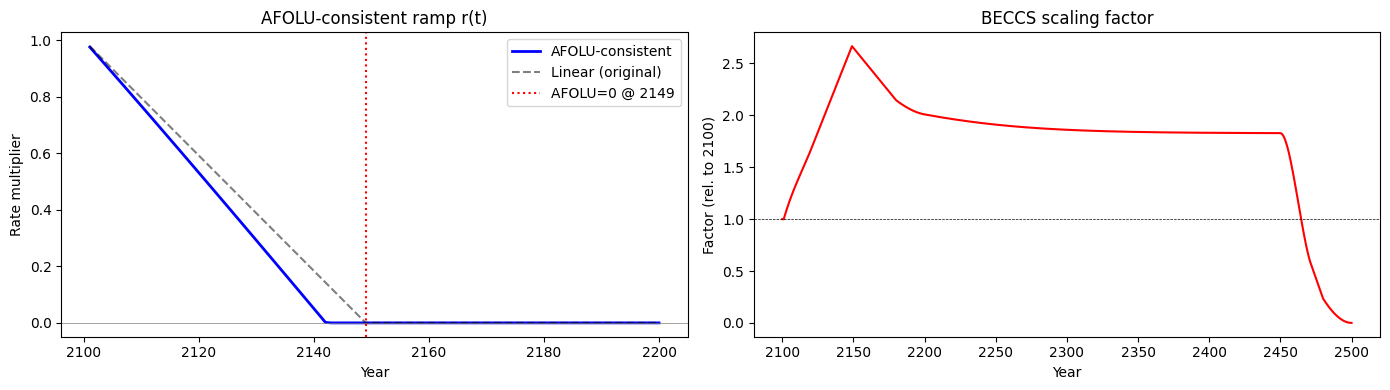

In [4]:
df = load_csv()
sc = filter_scenario(df)

linear_ramp = afolu_ramp(EXT_YEARS)
beccs = beccs_scaling_factors(sc)
beccs_dict = beccs.to_dict()

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

ax = axes[0]
ax.plot(EXT_YEARS[:100], derived_ramp_full[:100], 'b-', lw=2, label='AFOLU-consistent')
ax.plot(EXT_YEARS[:100], linear_ramp[:100], 'k--', lw=1.5, alpha=0.5, label='Linear (original)')
ax.axhline(0, color='gray', lw=0.5)
ax.axvline(cfg.YR_AFOLU_ZERO, color='r', ls=':', label=f'AFOLU=0 @ {cfg.YR_AFOLU_ZERO}')
ax.set_xlabel('Year'); ax.set_ylabel('Rate multiplier')
ax.set_title('AFOLU-consistent ramp r(t)'); ax.legend()

ax = axes[1]
beccs_yrs = np.array(sorted(beccs_dict.keys()))
beccs_vals = np.array([beccs_dict[y] for y in beccs_yrs])
ax.plot(beccs_yrs, beccs_vals, 'r-', lw=1.5)
ax.axhline(1, color='k', ls='--', lw=0.5)
ax.set_xlabel('Year'); ax.set_ylabel('Factor (rel. to 2100)')
ax.set_title('BECCS scaling factor')

plt.tight_layout(); plt.show()

## 4. Extend State Fractions (Active Ramp Period)

Forward-step all 13 state variables using per-cell rates multiplied by the **AFOLU-consistent ramp** $r(t)$, over the years where $r(t) > 0$. After the ramp reaches zero, all states are frozen.

`extend_states` handles:
- Multiplying each cell's rate by the ramp at each timestep
- Clamping negatives to zero
- Redirecting deficit area to `secdf` (secondary forest) as the residual
- Freezing fields after the ramp reaches zero

In [5]:
%%time
# Compute states over active ramp period, using AFOLU-consistent ramp
ext_states = extend_states(vals, rates, RAMP_YEARS, ramp=derived_ramp)

print(f"Extended {len(ext_states)} state variables over {len(RAMP_YEARS)} years")
print(f"Using AFOLU-consistent ramp (r(t) range: [{derived_ramp.min():.4f}, {derived_ramp.max():.4f}])")
for v in ['primf', 'secdf', 'c3ann']:
    arr = ext_states[v]
    print(f"  {v}: shape={arr.shape}, dtype={arr.dtype}, "
          f"range=[{np.nanmin(arr):.6f}, {np.nanmax(arr):.6f}]")

Extended 13 state variables over 42 years
Using AFOLU-consistent ramp (r(t) range: [0.0016, 0.9765])
  primf: shape=(42, 720, 1440), dtype=float64, range=[0.000000, 0.999998]
  secdf: shape=(42, 720, 1440), dtype=float64, range=[-0.417032, 0.998520]
  c3ann: shape=(42, 720, 1440), dtype=float64, range=[0.000000, 0.678695]
CPU times: user 3.17 s, sys: 450 ms, total: 3.62 s
Wall time: 3.65 s


## 5. Validate Per-Cell Conservation (Sum-to-One)

The per-cell sum of all 13 state fractions must equal 1.0 on every land cell, every year. Plot the maximum absolute deviation over time and confirm it stays below numerical tolerance.

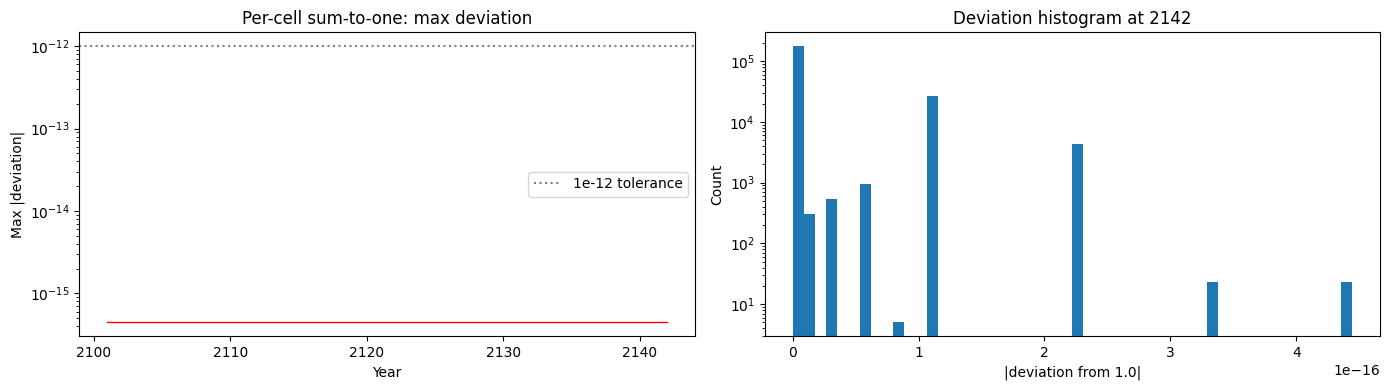

Max deviation over ramp years: 4.44e-16
PASS


In [6]:
# Per-cell total at 2100 (reference)
cell_total_2100 = np.zeros_like(vals['primf'])
for v in cfg.STATE_VARS:
    cell_total_2100 += np.where(np.isfinite(vals[v]), vals[v], 0.0)

# Check deviation at every ramp year
max_dev = np.zeros(len(RAMP_YEARS))
mean_dev = np.zeros(len(RAMP_YEARS))
for ti in range(len(RAMP_YEARS)):
    cell_sum = np.zeros_like(vals['primf'])
    for v in cfg.STATE_VARS:
        cell_sum += np.where(np.isfinite(ext_states[v][ti]), ext_states[v][ti], 0.0)
    dev = np.abs(cell_sum - cell_total_2100)
    dev_land = dev[land_mask]
    max_dev[ti] = np.max(dev_land)
    mean_dev[ti] = np.mean(dev_land)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

ax = axes[0]
ax.semilogy(RAMP_YEARS, max_dev, 'r-', lw=1)
ax.axhline(1e-12, color='gray', ls=':', label='1e-12 tolerance')
ax.set_xlabel('Year'); ax.set_ylabel('Max |deviation|')
ax.set_title('Per-cell sum-to-one: max deviation'); ax.legend()

ax = axes[1]
# Histogram of deviations at final ramp year
cell_sum_sample = np.zeros_like(vals['primf'])
for v in cfg.STATE_VARS:
    cell_sum_sample += np.where(np.isfinite(ext_states[v][-1]),
                                 ext_states[v][-1], 0.0)
dev_sample = np.abs(cell_sum_sample - cell_total_2100)[land_mask]
ax.hist(dev_sample, bins=50, log=True)
ax.set_xlabel('|deviation from 1.0|'); ax.set_ylabel('Count')
ax.set_title(f'Deviation histogram at {RAMP_YEARS[-1]}')

plt.tight_layout(); plt.show()
print(f"Max deviation over ramp years: {max_dev.max():.2e}")
print(f"PASS" if max_dev.max() < 1e-10 else "WARN: deviations exceed tolerance")

## 6. Validate Spatial Continuity Across the 2100 Join

Compare the first extension year (2101) against the last input year (2100). The difference should match the expected one-year rate change (rate x ramp(2101)).

Ramp multiplier at 2101: 0.976544

Variable      2100 gsum    2101 gsum         Diff     Expected
--------------------------------------------------------------
primf        33423.7228   33406.8608     -16.8620     -16.8620
secdf        45704.0355   45784.5653      80.5298      82.6095
primn        46183.8403   46180.5687      -3.2716      -3.2716
secdn        35869.6265   35890.8968      21.2704      21.2502
c3ann         8995.2580    8961.5703     -33.6876     -34.0401
c3nfx         3938.4349    3913.8130     -24.6219     -24.6219
c3per         2923.5433    2917.4196      -6.1236      -6.2865
c4ann         3213.7958    3204.0294      -9.7665      -9.7665
c4per         2054.7679    2056.7730       2.0051       1.8930
pastr         8355.0120    8351.2966      -3.7153      -3.7153
range        34349.6519   34347.9759      -1.6760      -1.6760
urban         1641.0747    1635.6993      -5.3753      -5.3753
pltns         2640.2194    2641.5140       1.2946       1.2946


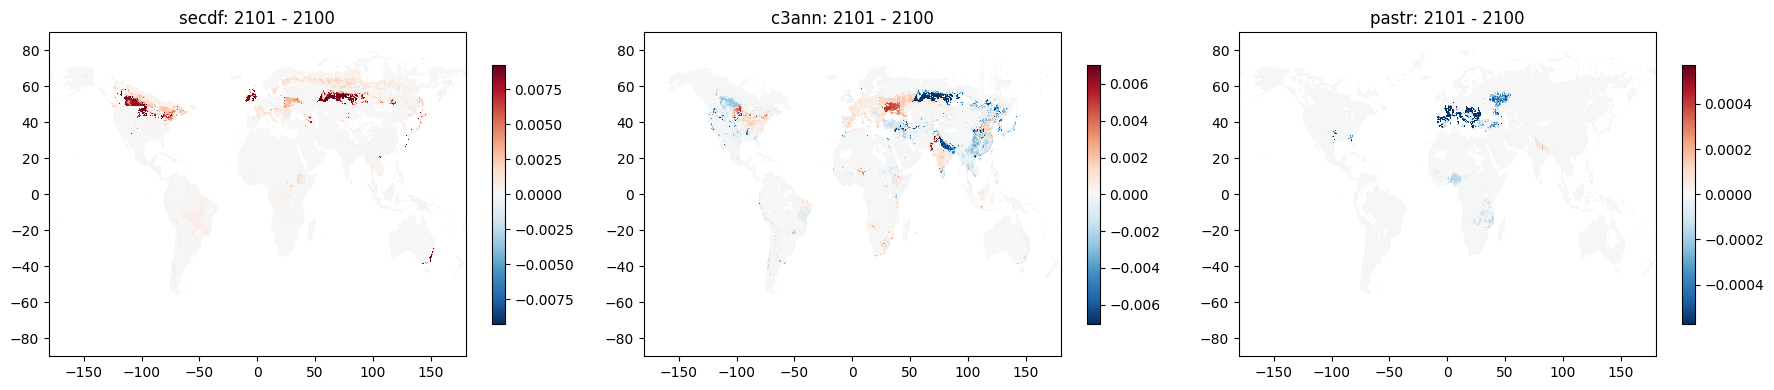

In [7]:
# Expected first-year ramp multiplier (from AFOLU-consistent ramp, not linear)
mult_2101 = derived_ramp_full[0]
print(f"Ramp multiplier at 2101: {mult_2101:.6f}\n")

print(f"{'Variable':10s} {'2100 gsum':>12s} {'2101 gsum':>12s} {'Diff':>12s} {'Expected':>12s}")
print("-" * 62)
for v in cfg.STATE_VARS:
    s_2100 = np.nansum(vals[v])
    s_2101 = np.nansum(ext_states[v][0])
    diff = s_2101 - s_2100
    expected = np.nansum(rates[v]) * mult_2101
    print(f"{v:10s} {s_2100:12.4f} {s_2101:12.4f} {diff:12.4f} {expected:12.4f}")

# Map of largest per-cell jump for secdf
fig, axes = plt.subplots(1, 3, figsize=(18, 4))
for ax, v in zip(axes, ['secdf', 'c3ann', 'pastr']):
    jump = ext_states[v][0] - vals[v]
    im = ax.pcolormesh(lon, lat, jump, cmap='RdBu_r', shading='auto',
                       vmin=-np.nanpercentile(np.abs(jump[land_mask]), 99),
                       vmax=np.nanpercentile(np.abs(jump[land_mask]), 99))
    ax.set_title(f'{v}: 2101 - 2100')
    plt.colorbar(im, ax=ax, shrink=0.8)
plt.tight_layout(); plt.show()

## 7. Extend Biofuel Crop Fractions via BECCS Scaling

Scale the 2100 `crpbiof` field by the BECCS factor each year, capping at 1.0 per cell. Compare global achieved vs target scaling.

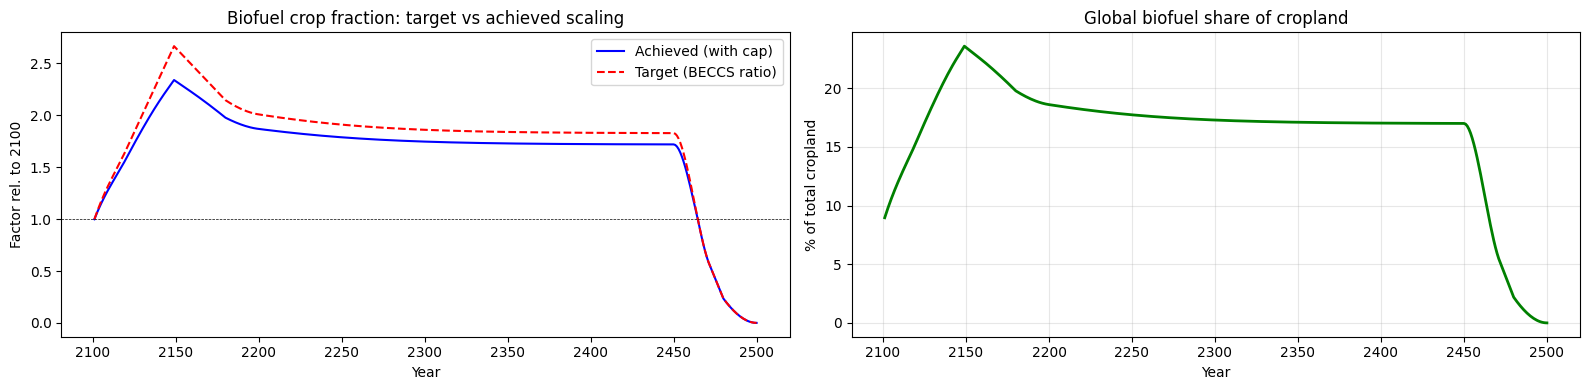

crpbiof_ext shape: (400, 720, 1440)
Peak achieved factor: 2.340 at year 2149
Cells hitting 1.0 cap (crpbiof=100% of local cropland): 682,359

Global biofuel share of cropland:
  At 2100: 8.9%
  Peak:    23.6% at year 2149
  At 2500: 0.0%
CPU times: user 7.93 s, sys: 187 ms, total: 8.12 s
Wall time: 8.17 s


In [8]:
%%time
crpbiof_ext = extend_biofuel(crpbiof_2100, beccs_dict, EXT_YEARS)

# Compare achieved vs target
sum_2100 = np.nansum(crpbiof_2100)
achieved = np.array([np.nansum(crpbiof_ext[t]) for t in range(len(EXT_YEARS))]) / sum_2100
target = np.array([beccs_dict.get(int(y), 1.0) for y in EXT_YEARS])

fig, axes = plt.subplots(1, 2, figsize=(16, 4))

ax = axes[0]
ax.plot(EXT_YEARS, achieved, 'b-', label='Achieved (with cap)')
ax.plot(EXT_YEARS, target, 'r--', label='Target (BECCS ratio)')
ax.axhline(1, color='k', ls='--', lw=0.5)
ax.set_xlabel('Year'); ax.set_ylabel('Factor rel. to 2100')
ax.set_title('Biofuel crop fraction: target vs achieved scaling')
ax.legend()

# Global biofuel share of total cropland over time
crop_vars = ['c3ann', 'c3nfx', 'c3per', 'c4ann', 'c4per']
# Total crop fraction at 2100
crop_total_2100 = sum(np.where(np.isfinite(vals[v]), vals[v], 0.0) for v in crop_vars)
# Biofuel area fraction = crpbiof * crop_total  (crpbiof is fraction of cropland)
biof_area_2100 = np.nansum(crpbiof_2100 * crop_total_2100)
crop_area_2100 = np.nansum(crop_total_2100)
# Track the global biofuel share over extension years
# During ramp: crop areas change; after ramp: frozen
n_ramp = len(RAMP_YEARS)
global_biof_share = np.zeros(len(EXT_YEARS))
for ti in range(len(EXT_YEARS)):
    if ti < n_ramp:
        crop_tot = sum(np.where(np.isfinite(ext_states[v][ti]), ext_states[v][ti], 0.0)
                       for v in crop_vars)
    else:
        crop_tot = sum(np.where(np.isfinite(ext_states[v][-1]), ext_states[v][-1], 0.0)
                       for v in crop_vars)
    biof_area = np.nansum(crpbiof_ext[ti] * crop_tot)
    crop_area = np.nansum(crop_tot)
    global_biof_share[ti] = biof_area / crop_area if crop_area > 0 else 0.0

ax = axes[1]
ax.plot(EXT_YEARS, global_biof_share * 100, 'g-', lw=2)
ax.set_xlabel('Year'); ax.set_ylabel('% of total cropland')
ax.set_title('Global biofuel share of cropland')
ax.grid(True, alpha=0.3)

plt.tight_layout(); plt.show()

print(f"crpbiof_ext shape: {crpbiof_ext.shape}")
print(f"Peak achieved factor: {achieved.max():.3f} at year {EXT_YEARS[np.argmax(achieved)]}")
n_saturated = np.sum(crpbiof_ext > 0.999)
print(f"Cells hitting 1.0 cap (crpbiof=100% of local cropland): {n_saturated:,}")
print(f"\nGlobal biofuel share of cropland:")
print(f"  At 2100: {biof_area_2100/crop_area_2100*100:.1f}%")
print(f"  Peak:    {global_biof_share.max()*100:.1f}% at year {EXT_YEARS[np.argmax(global_biof_share)]}")
print(f"  At 2500: {global_biof_share[-1]*100:.1f}%")

## 8. Extend Management and Transition Fields

- **Hold-constant variables** (wood harvest, fuelwood, irrigation, fertiliser): replicate the 2100 field for all extension years.
- **Transition matrices**: year-on-year differences of extended states. Zero after the ramp ends (no more land-use change).

In [9]:
# Hold-constant management variables: keep 2D field only (no 400-year replication)
ext_mgmt = {}
for v in cfg.MGMT_HOLD_CONSTANT:
    if v in ds_mgmt:
        ext_mgmt[v] = ds_mgmt[v].isel(time=-1).values
        print(f"  {v}: held constant, 2D shape={ext_mgmt[v].shape}")
    else:
        print(f"  {v}: NOT in management dataset, skipping")

# Biofuel management: crpbiof already done above; handle sub-components
for v in cfg.MGMT_BIOFUEL_VARS:
    if v == 'crpbiof':
        continue  # already extended via BECCS scaling
    if v in ds_mgmt:
        field_2100 = ds_mgmt[v].isel(time=-1).values
        ext_mgmt[v] = extend_biofuel(field_2100, beccs_dict, EXT_YEARS)
        print(f"  {v}: BECCS-scaled, shape={ext_mgmt[v].shape}")

print(f"\nTotal management variables extended: {len(ext_mgmt)}")

  rndwd: held constant, 2D shape=(720, 1440)
  fulwd: held constant, 2D shape=(720, 1440)
  pltns_wdprd: held constant, 2D shape=(720, 1440)
  pltns_bfuel: held constant, 2D shape=(720, 1440)
  irrig_c3ann: held constant, 2D shape=(720, 1440)
  irrig_c3nfx: held constant, 2D shape=(720, 1440)
  irrig_c3per: held constant, 2D shape=(720, 1440)
  irrig_c4ann: held constant, 2D shape=(720, 1440)
  irrig_c4per: held constant, 2D shape=(720, 1440)
  fertl_c3ann: held constant, 2D shape=(720, 1440)
  fertl_c3nfx: held constant, 2D shape=(720, 1440)
  fertl_c3per: held constant, 2D shape=(720, 1440)
  fertl_c4ann: held constant, 2D shape=(720, 1440)
  fertl_c4per: held constant, 2D shape=(720, 1440)
  crpbf_c3per: BECCS-scaled, shape=(400, 720, 1440)
  crpbf_c4per: BECCS-scaled, shape=(400, 720, 1440)

Total management variables extended: 16


<![CDATA[## 9. Spot-Check Maps: Selected Variables at 2100, 2125, 2150

Visual sanity check: confirm smooth spatial evolution and no obvious boundary artefacts at the 2100 join or the ramp endpoint (2149/2150).]]>

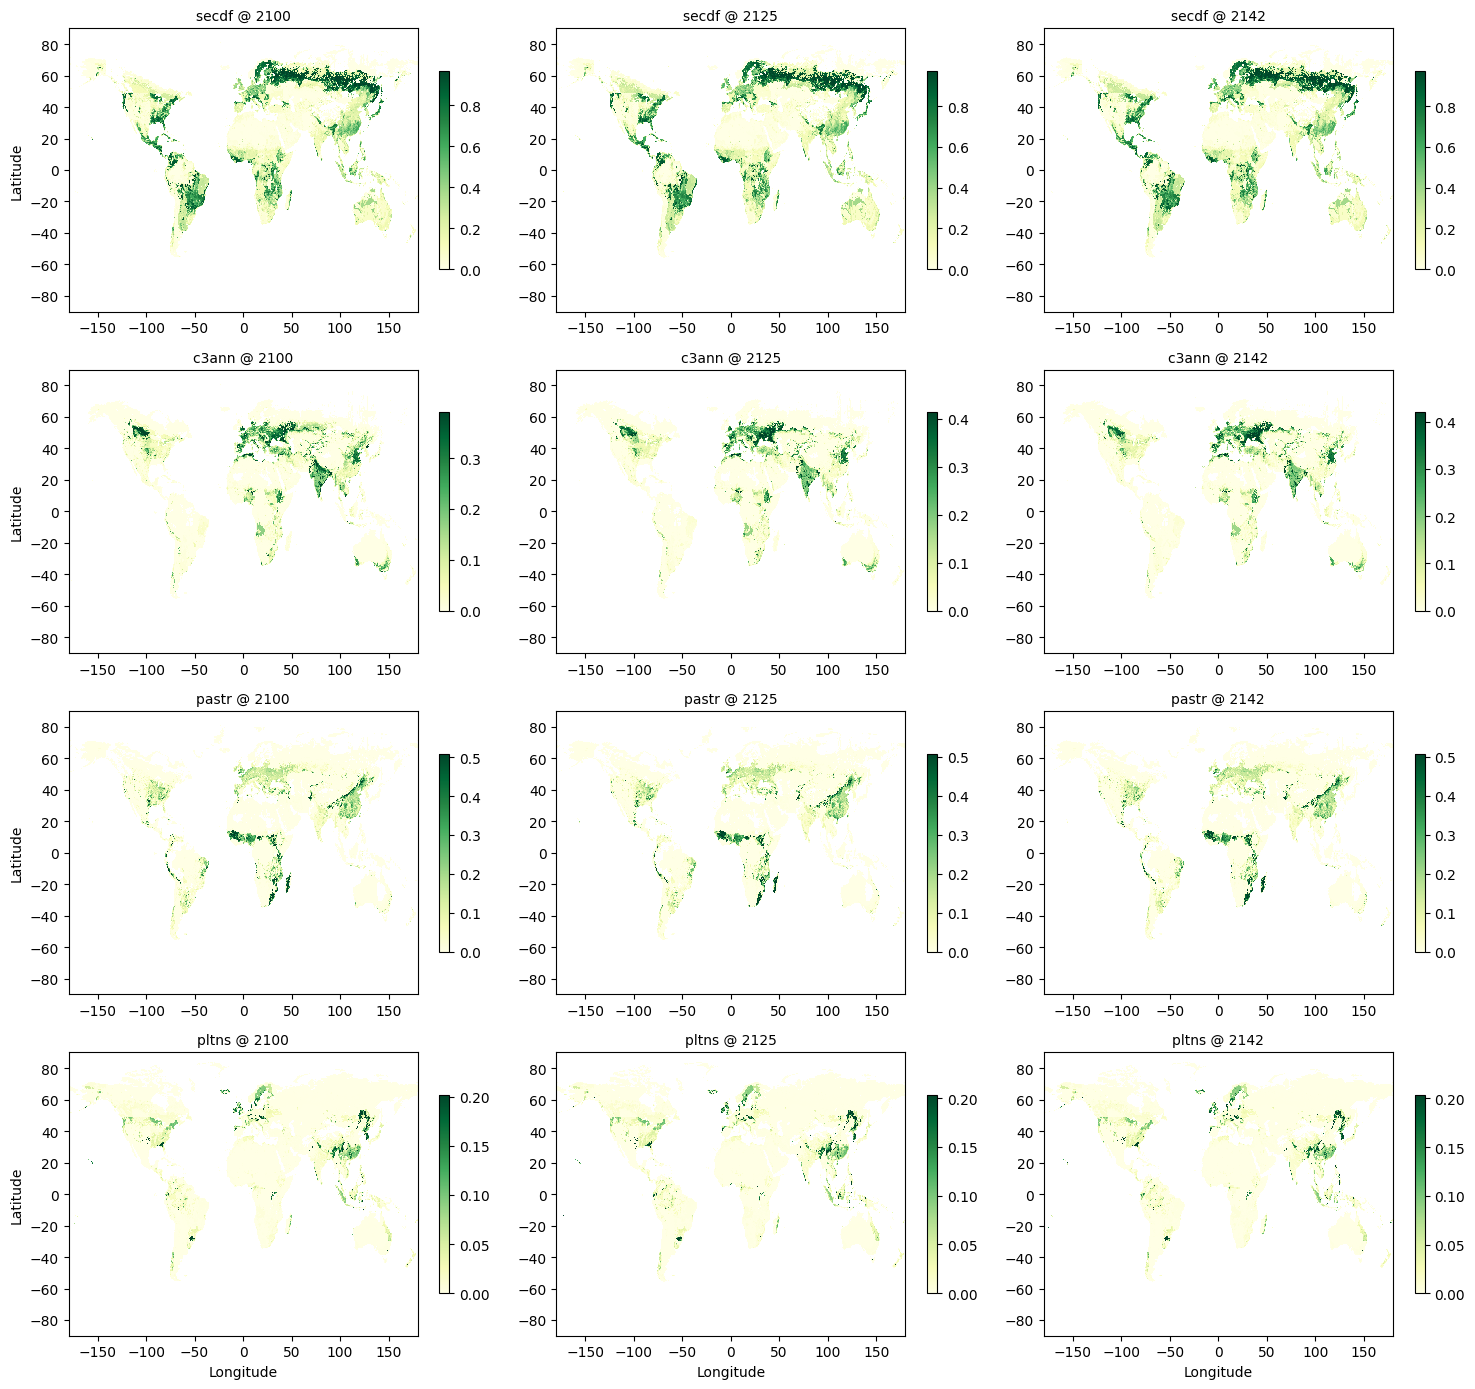

In [10]:
check_vars = ['secdf', 'c3ann', 'pastr', 'pltns']
check_years = [2100, 2125, int(RAMP_YEARS[-1])]  # last ramp year instead of 2150

fig, axes = plt.subplots(len(check_vars), len(check_years),
                          figsize=(5 * len(check_years), 3.5 * len(check_vars)))

for row, v in enumerate(check_vars):
    for col, yr in enumerate(check_years):
        ax = axes[row, col]
        if yr == 2100:
            field = vals[v]
        else:
            ti = min(np.searchsorted(RAMP_YEARS, yr), len(RAMP_YEARS) - 1)
            field = ext_states[v][ti]
        vmax = np.nanpercentile(np.abs(field[land_mask]), 99)
        im = ax.pcolormesh(lon, lat, field, cmap='YlGn', shading='auto',
                           vmin=0, vmax=max(vmax, 1e-6))
        ax.set_title(f'{v} @ {yr}', fontsize=10)
        plt.colorbar(im, ax=ax, shrink=0.7)
        if col == 0:
            ax.set_ylabel('Latitude')
        if row == len(check_vars) - 1:
            ax.set_xlabel('Longitude')

plt.tight_layout(); plt.show()

<![CDATA[## 10. Global Timeseries: Extended State Fractions (Ramp Period)

Stacked area plot of globally-summed state fractions spanning the ramp period, plus the conservation check. After 2150 all values are frozen.]]>

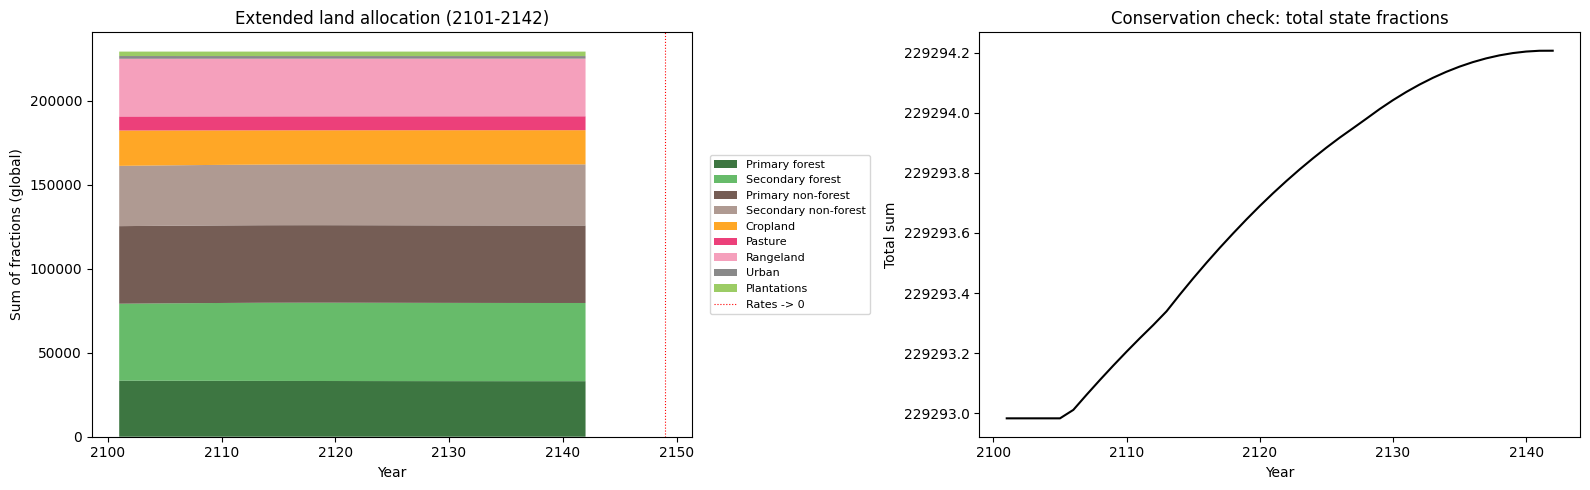

In [11]:
groups = {
    'Primary forest':       ['primf'],
    'Secondary forest':     ['secdf'],
    'Primary non-forest':   ['primn'],
    'Secondary non-forest': ['secdn'],
    'Cropland':             ['c3ann', 'c3nfx', 'c3per', 'c4ann', 'c4per'],
    'Pasture':              ['pastr'],
    'Rangeland':            ['range'],
    'Urban':                ['urban'],
    'Plantations':          ['pltns'],
}
colors = ['#1b5e20', '#4caf50', '#5d4037', '#a1887f',
          '#ff9800', '#e91e63', '#f48fb1', '#757575', '#8bc34a']

# Global sums for ramp period
group_sums = {}
for label, varlist in groups.items():
    ts = np.array([
        sum(np.nansum(ext_states[v][t]) for v in varlist)
        for t in range(len(RAMP_YEARS))
    ])
    group_sums[label] = ts

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

ax = axes[0]
labels = list(groups.keys())
data = np.array([group_sums[l] for l in labels])
ax.stackplot(RAMP_YEARS, data, labels=labels, colors=colors, alpha=0.85)
ax.axvline(cfg.YR_AFOLU_ZERO, color='r', ls=':', lw=0.8, label='Rates -> 0')
ax.set_xlabel('Year'); ax.set_ylabel('Sum of fractions (global)')
ax.set_title(f'Extended land allocation ({RAMP_YEARS[0]}-{RAMP_YEARS[-1]})')
ax.legend(loc='center left', bbox_to_anchor=(1.02, 0.5), fontsize=8)

ax = axes[1]
total = data.sum(axis=0)
ax.plot(RAMP_YEARS, total, 'k-', lw=1.5)
ax.set_xlabel('Year'); ax.set_ylabel('Total sum')
ax.set_title('Conservation check: total state fractions')
ax.ticklabel_format(useOffset=False)

plt.tight_layout(); plt.show()

## 11. Output Files (Grouped by Source Input File)

Each output file mirrors the variable grouping of its source input file.
Management is split into transient and static since the time dimensions differ.

| # | Source input | Output file | Variables | Timesteps |
|:-:|:------------|:------------|:----------|:---------:|
| 1 | `output_annual_2024_states_step4.nc` | `…_extension_transient_2101-YYYY.nc` | 13 state fractions | active ramp |
| 2 | `biof_MAGPIE_LUH3.nc` | `…_extension_transient_2101-2500.nc` | crpbiof | 400 |
| 3 | `output_annual_summed_management_step5.nc` | `…_extension_transient_2101-2500.nc` | crpbf_c3per, crpbf_c4per | 400 |
| 4 | `output_annual_summed_management_step5.nc` | `…_extension_static.nc` | 14 hold-constant mgmt vars | 1 |

All files use:
- **zlib level 4**, **float32**, per-timestep chunks `(1, nlat, nlon)`
- CF-1.6 variable attributes copied from input
- Provenance global attributes (source model, scenario, extension method using **AFOLU-consistent ramp**, source files)

In [12]:
os.makedirs(cfg.OUTPUT_DIR, exist_ok=True)

# --- Variable metadata (mirrors input CF attributes) ---
VAR_META = {
    # State variables
    'primf': {'long_name': 'forested primary land',           'units': 'share of carea'},
    'secdf': {'long_name': 'potentially forested secondary land', 'units': 'share of carea'},
    'primn': {'long_name': 'non-forested primary land',       'units': 'share of carea'},
    'secdn': {'long_name': 'potentially non-forested secondary land', 'units': 'share of carea'},
    'c3ann': {'long_name': 'C3 annual crops',                 'units': 'share of carea'},
    'c3nfx': {'long_name': 'C3 nitrogen-fixing crops',        'units': 'share of carea'},
    'c3per': {'long_name': 'C3 perennial crops',              'units': 'share of carea'},
    'c4ann': {'long_name': 'C4 annual crops',                 'units': 'share of carea'},
    'c4per': {'long_name': 'C4 perennial crops',              'units': 'share of carea'},
    'pastr': {'long_name': 'managed pasture',                 'units': 'share of carea'},
    'range': {'long_name': 'rangeland',                       'units': 'share of carea'},
    'urban': {'long_name': 'urban land',                      'units': 'share of carea'},
    'pltns': {'long_name': 'plantation forests',              'units': 'share of carea'},
    # BECCS-scaled biofuel
    'crpbiof':    {'long_name': 'biofuel fraction of cropland',                         'units': 'fraction of cropland area'},
    'crpbf_c3per':{'long_name': 'C3 perennial crops grown as second-generation biofuels','units': 'share of c3per'},
    'crpbf_c4per':{'long_name': 'C4 perennial crops grown as second-generation biofuels','units': 'share of c4per'},
    # Hold-constant management
    'rndwd':       {'long_name': 'industrial roundwood fraction of wood harvest biomass carbon', 'units': 'share of bioh'},
    'fulwd':       {'long_name': 'fuelwood fraction of wood harvest biomass carbon',             'units': 'share of bioh'},
    'pltns_wdprd': {'long_name': 'fraction of harvested plantations biomass used for wood products', 'units': 'share of pltns'},
    'pltns_bfuel': {'long_name': 'fraction of harvested plantations biomass used for bioenergy',     'units': 'share of pltns'},
    'irrig_c3ann': {'long_name': 'irrigated fraction of C3 annual crops',      'units': 'share of c3ann'},
    'irrig_c3nfx': {'long_name': 'irrigated fraction of C3 nitrogen-fixing crops','units': 'share of c3nfx'},
    'irrig_c3per': {'long_name': 'irrigated fraction of C3 perennial crops',   'units': 'share of c3per'},
    'irrig_c4ann': {'long_name': 'irrigated fraction of C4 annual crops',      'units': 'share of c4ann'},
    'irrig_c4per': {'long_name': 'irrigated fraction of C4 perennial crops',   'units': 'share of c4per'},
    'fertl_c3ann': {'long_name': 'fertilization rate for C3 annual crops',     'units': 'kg ha-1 yr-1'},
    'fertl_c3nfx': {'long_name': 'fertilization rate for C3 nitrogen-fixing crops','units': 'kg ha-1 yr-1'},
    'fertl_c3per': {'long_name': 'fertilization rate for C3 perennial crops',  'units': 'kg ha-1 yr-1'},
    'fertl_c4ann': {'long_name': 'fertilization rate for C4 annual crops',     'units': 'kg ha-1 yr-1'},
    'fertl_c4per': {'long_name': 'fertilization rate for C4 perennial crops',  'units': 'kg ha-1 yr-1'},
}

nlat, nlon = len(lat), len(lon)

# --- Shared global attributes ---
global_attrs = {
    'Conventions': 'CF-1.6',
    'activity_id': 'ScenarioMIP',
    'source_model': cfg.MODEL,
    'source_scenario': cfg.SCENARIO,
    'institution': 'CICERO Center for International Climate Research',
    'extension_method': (
        'Per-cell rates of change from 2100 multiplied by an AFOLU-consistent '
        'ramp r(t) derived by inverting a calibrated cohort-based carbon cycle '
        'model (see notebook 02). Negatives clamped, deficit absorbed by secdf. '
        'Biofuel fractions scaled by BECCS ratio. '
        'Management fields held constant post-2100.'
    ),
    'source_states_file': cfg.STATES_FILE.name,
    'source_management_file': cfg.MGMT_FILE.name,
    'source_csv_file': cfg.CSV_FILE.name,
    'creation_date': datetime.utcnow().isoformat() + 'Z',
    'grid_label': 'gn',
    'frequency': 'yr',
    'nominal_resolution': '50 km',
}

# --- Helper: build a DataArray with CF attrs ---
def _make_da(varname, data):
    meta = VAR_META.get(varname, {})
    return xr.DataArray(
        data.astype(np.float32),
        dims=['time', 'lat', 'lon'],
        attrs={
            '_FillValue': np.float32(1e20),
            'cell_methods': 'time:mean',
            'standard_name': 'area_fraction',
            **meta,
        },
    )

# --- Source file stems ---
STATES_STEM = cfg.STATES_FILE.stem
MGMT_STEM   = cfg.MGMT_FILE.stem
BIOF_STEM   = cfg.BIOF_FILE.stem

# ============================================================
# FILE 1 — States (transient, active ramp period)
# ext_states already contains only ramp years
# ============================================================
state_dvars = {v: _make_da(v, ext_states[v]) for v in cfg.STATE_VARS}
ds_states_out = xr.Dataset(
    state_dvars,
    coords={'time': RAMP_YEARS.astype(np.float64), 'lat': lat, 'lon': lon},
)
ds_states_out.attrs = {
    **global_attrs,
    'title': f'LUH state extension ({RAMP_YEARS[0]}-{RAMP_YEARS[-1]})',
    'variable_id': 'multiple-states',
    'dataset_category': 'landState',
    'reconstruction_notes': (
        f'Contains the active ramp period {RAMP_YEARS[0]}-{RAMP_YEARS[-1]} '
        f'using the AFOLU-consistent ramp from notebook 02. '
        f'For {int(RAMP_YEARS[-1])+1}-{cfg.YR_END_OUTPUT} repeat the final timestep.'
    ),
}
fname_states = f'{STATES_STEM}_extension_transient_{RAMP_YEARS[0]}-{RAMP_YEARS[-1]}.nc'

# Free the large float64 arrays now that they're copied to float32 in the Dataset
del ext_states
import gc; gc.collect()

# ============================================================
# FILE 2 — Biofuel / crpbiof (transient, full 2101-2500)
# ============================================================
ds_biof_out = xr.Dataset(
    {'crpbiof': _make_da('crpbiof', crpbiof_ext)},
    coords={'time': EXT_YEARS.astype(np.float64), 'lat': lat, 'lon': lon},
)
ds_biof_out.attrs = {
    **global_attrs,
    'title': f'LUH biofuel extension ({EXT_YEARS[0]}-{EXT_YEARS[-1]})',
    'variable_id': 'crpbiof',
    'dataset_category': 'landManagement',
}
fname_biof = f'{BIOF_STEM}_extension_transient_{EXT_YEARS[0]}-{EXT_YEARS[-1]}.nc'

# ============================================================
# FILE 3 — Management transient (BECCS-scaled vars, 2101-2500)
# ============================================================
mgmt_trans_dvars = {}
for v in ('crpbf_c3per', 'crpbf_c4per'):
    if v in ext_mgmt:
        mgmt_trans_dvars[v] = _make_da(v, np.asarray(ext_mgmt[v]))

ds_mgmt_trans_out = xr.Dataset(
    mgmt_trans_dvars,
    coords={'time': EXT_YEARS.astype(np.float64), 'lat': lat, 'lon': lon},
)
ds_mgmt_trans_out.attrs = {
    **global_attrs,
    'title': f'LUH management extension – transient ({EXT_YEARS[0]}-{EXT_YEARS[-1]})',
    'variable_id': 'multiple-management',
    'dataset_category': 'landManagement',
}
fname_mgmt_trans = f'{MGMT_STEM}_extension_transient_{EXT_YEARS[0]}-{EXT_YEARS[-1]}.nc'

# ============================================================
# FILE 4 — Management static (hold-constant vars, single timestep)
# ext_mgmt hold-constant entries are 2D arrays
# ============================================================
mgmt_static_dvars = {}
for v in sorted(cfg.MGMT_HOLD_CONSTANT):
    if v not in ext_mgmt:
        continue
    # Wrap 2D field as (1, lat, lon)
    mgmt_static_dvars[v] = _make_da(v, ext_mgmt[v][np.newaxis])

ds_mgmt_static_out = xr.Dataset(
    mgmt_static_dvars,
    coords={'time': EXT_YEARS[0:1].astype(np.float64), 'lat': lat, 'lon': lon},
)
ds_mgmt_static_out.attrs = {
    **global_attrs,
    'title': 'LUH management extension – static (constant at 2100)',
    'variable_id': 'multiple-management',
    'dataset_category': 'landManagement',
    'reconstruction_notes': (
        'All variables are constant at their 2100 value for extension years 2101-2500.'
    ),
}
fname_mgmt_static = f'{MGMT_STEM}_extension_static.nc'

# --- Output plan ---
output_plan = [
    (ds_states_out,      fname_states),
    (ds_biof_out,        fname_biof),
    (ds_mgmt_trans_out,  fname_mgmt_trans),
    (ds_mgmt_static_out, fname_mgmt_static),
]

print(f"Output plan: {len(output_plan)} files")
for ds, fname in output_plan:
    nt = ds.sizes['time']
    nvars = len([v for v in ds.data_vars])
    print(f"  {fname}")
    print(f"    {nvars} vars, {nt} timesteps: {list(ds.data_vars)}")

/scratch/tmp/ipykernel_2111755/2080442860.py:59: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  'creation_date': datetime.utcnow().isoformat() + 'Z',


Output plan: 4 files
  output_annual_2024_states_step4_extension_transient_2101-2142.nc
    13 vars, 42 timesteps: ['primf', 'secdf', 'primn', 'secdn', 'c3ann', 'c3nfx', 'c3per', 'c4ann', 'c4per', 'pastr', 'range', 'urban', 'pltns']
  biof_MAGPIE_LUH3_extension_transient_2101-2500.nc
    1 vars, 400 timesteps: ['crpbiof']
  output_annual_summed_management_step5_extension_transient_2101-2500.nc
    2 vars, 400 timesteps: ['crpbf_c3per', 'crpbf_c4per']
  output_annual_summed_management_step5_extension_static.nc
    14 vars, 1 timesteps: ['fertl_c3ann', 'fertl_c3nfx', 'fertl_c3per', 'fertl_c4ann', 'fertl_c4per', 'fulwd', 'irrig_c3ann', 'irrig_c3nfx', 'irrig_c3per', 'irrig_c4ann', 'irrig_c4per', 'pltns_bfuel', 'pltns_wdprd', 'rndwd']


In [14]:
%%time
import gc

# --- Write output files, freeing each after write ---
comp = {'zlib': True, 'complevel': 4, 'dtype': 'float32'}
total_bytes = 0

for ds, fname in output_plan:
    print(f"Writing {fname}...")
    path = cfg.OUTPUT_DIR / fname
    enc = {v: {**comp, 'chunksizes': (1, nlat, nlon)} for v in ds.data_vars}
    ds.to_netcdf(path, encoding=enc)
    sz = os.path.getsize(path)
    total_bytes += sz
    print(f"  {sz / 1e6:7.1f} MB  {fname}")
    ds.close()

gc.collect()
print(f"\n  {total_bytes / 1e6:7.1f} MB  TOTAL ({total_bytes / 1e9:.2f} GB)")
print(f"\nFiles written to: {cfg.OUTPUT_DIR}")

Writing output_annual_2024_states_step4_extension_transient_2101-2142.nc...
CPU times: user 2.17 ms, sys: 12 μs, total: 2.18 ms
Wall time: 1.64 ms


PermissionError: [Errno 13] Permission denied: '/div/no-backup-nac/users/bensan/extend-luh/output/output_annual_2024_states_step4_extension_transient_2101-2142.nc'

In [ ]:
# Clean up
ds_states.close()
ds_mgmt.close()
ds_biof.close()
print("All input datasets closed.")

All input datasets closed.
